# Embeddings 

Author: Umberto Michelucci, umberto.michelucci@hslu.ch

![Embeddings Diagram](embeddings2.png)

In [ ]:
#!pip install openai scikit-learn matplotlib pandas

In [12]:
from openai import OpenAI
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pandas as pd

In [3]:
# Path to the file on the Desktop
key_path = Path.home() / "Desktop" / "api-key.txt"

# Read the key
api_key = key_path.read_text().strip()

# Create client
client = OpenAI(api_key=api_key)

In [34]:
# Words with semantic relationships

words = [
    "king",
    "man",
    "woman",
    "apple",
    "banana",
    "car",
    "truck",
    "doctor",
    "nurse",
    "ananas",
    "go"
]

In [35]:
# Convert each word into an embedding vector

response = client.embeddings.create(
    model="text-embedding-3-small",
    input=words
)

embeddings = [item.embedding for item in response.data]

print("Embedding dimension:", len(embeddings[0]))

Embedding dimension: 1536


In [36]:
# PCA reduces the vectors from high dimensions to 2D

pca = PCA(n_components=2)

reduced_embeddings = pca.fit_transform(embeddings)

print(reduced_embeddings.shape)

(11, 2)


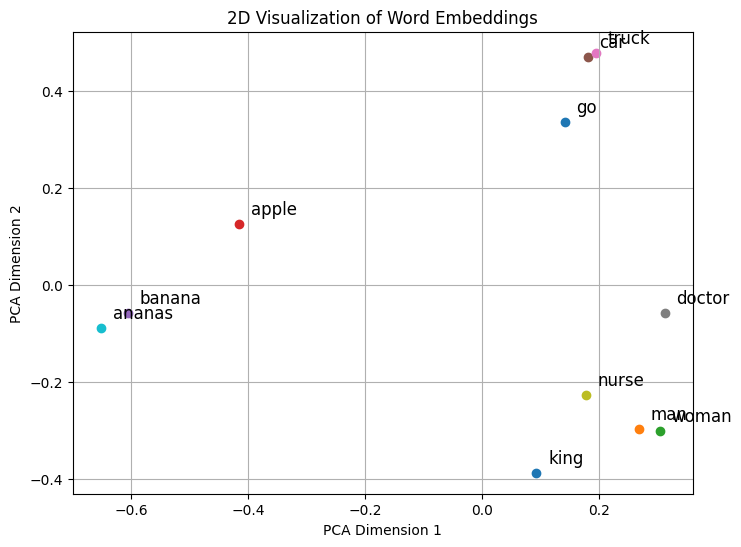

In [37]:
# Plot the embeddings in 2D

plt.figure(figsize=(8, 6))

for i, word in enumerate(words):

    x = reduced_embeddings[i, 0]
    y = reduced_embeddings[i, 1]

    plt.scatter(x, y)
    plt.text(x + 0.02, y + 0.02, word, fontsize=12)

plt.title("2D Visualization of Word Embeddings")

plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")

plt.grid(True)

plt.show()

![Embeddings Diagram](embeddings1.png)

## What happened?

The embedding model converted each word into a numerical vector.

The vectors originally had more than 1000 dimensions.

PCA projected these vectors into 2 dimensions while trying to preserve
their relative distances.

Words with related meaning tend to appear close together.

Examples:
- king and queen
- apple and banana
- car and truck

This demonstrates one of the key ideas behind embeddings:

semantic meaning becomes geometry.

# Similarities

# Similarity Between Embeddings

Embeddings are vector representations of objects such as words, sentences, images, or documents.

Given two embeddings

$$
\mathbf{x} = (x_1, x_2, \dots, x_n)
$$

and

$$
\mathbf{y} = (y_1, y_2, \dots, y_n)
$$

we want to measure how *similar* they are.

---

# Why Similarity Matters

Similarity measures are used in:

- Semantic search
- Recommendation systems
- Retrieval-Augmented Generation (RAG)
- Clustering
- Classification
- Image retrieval
- Anomaly detection

The main idea is:

> Similar objects should have embeddings that are close to each other in vector space.

---

# Geometric Interpretation

An embedding can be interpreted as a point in a high-dimensional space.

Two vectors can be:

- close together
- far apart
- pointing in similar directions
- orthogonal
- opposite

Different similarity metrics capture different notions of similarity.

---

# Dot Product

The simplest similarity measure is the **dot product**.

Given two vectors:

$$
\mathbf{x} \cdot \mathbf{y}
=
\sum_{i=1}^{n} x_i y_i
$$

A large dot product means:

- vectors point in similar directions
- and/or they have large magnitudes

---

# Euclidean Distance

A distance metric often used is the Euclidean distance:

$$
d(\mathbf{x}, \mathbf{y})
=
\sqrt{
\sum_{i=1}^{n}
(x_i - y_i)^2
}
$$

Properties:

- Smaller distance $\rightarrow$ more similar
- Larger distance $\rightarrow$ less similar

---

# Cosine Similarity

The most common similarity measure for embeddings is **cosine similarity**.

It measures the angle between two vectors.

$$
\text{cosine\_similarity}(\mathbf{x}, \mathbf{y})
=
\frac{
\mathbf{x} \cdot \mathbf{y}
}{
\|\mathbf{x}\| \|\mathbf{y}\|
}
$$

where

$$
\|\mathbf{x}\|
=
\sqrt{
\sum_{i=1}^{n} x_i^2
}
$$

is the vector norm.

---

# Interpretation of Cosine Similarity

Cosine similarity values lie in:

$$
[-1, 1]
$$

Interpretation:

| Value | Meaning |
|---|---|
| $1$ | Same direction |
| $0$ | Orthogonal |
| $-1$ | Opposite direction |

For many embeddings (especially from neural networks), values are often between:

$$
[0,1]
$$

---

# Why Cosine Similarity is Popular

Cosine similarity ignores vector magnitude and focuses only on direction.

This is important because:

- two embeddings may have different lengths
- but still encode similar semantic meaning

Thus cosine similarity is particularly useful in:

- NLP embeddings
- sentence transformers
- semantic search
- LLM retrieval systems

---

# Relationship Between Dot Product and Cosine Similarity

Cosine similarity can be written as:

$$
\text{cosine\_similarity}(\mathbf{x}, \mathbf{y})
=
\frac{
\mathbf{x} \cdot \mathbf{y}
}{
\|\mathbf{x}\| \|\mathbf{y}\|
}
$$

If vectors are normalized:

$$
\|\mathbf{x}\| = \|\mathbf{y}\| = 1
$$

then:

$$
\text{cosine\_similarity}(\mathbf{x}, \mathbf{y})
=
\mathbf{x} \cdot \mathbf{y}
$$

This is why many embedding systems normalize vectors before retrieval.

---

# Example

Consider:

$$
\mathbf{x} = (1,2,3)
$$

$$
\mathbf{y} = (2,4,6)
$$

These vectors point in exactly the same direction.

Their cosine similarity is:

$$
1
$$

even though their magnitudes are different.

---

# Cosine Distance

Sometimes we define a distance instead of a similarity:

$$
d_{\text{cos}}(\mathbf{x}, \mathbf{y})
=
1 -
\text{cosine\_similarity}(\mathbf{x}, \mathbf{y})
$$

This converts similarity into a distance-like quantity.

---

# Summary

| Metric | Formula | Measures |
|---|---|---|
| Dot Product | $\mathbf{x} \cdot \mathbf{y}$ | Alignment + magnitude |
| Euclidean Distance | $\|\mathbf{x}-\mathbf{y}\|$ | Geometric distance |
| Cosine Similarity | $\frac{\mathbf{x}\cdot\mathbf{y}}{\|\mathbf{x}\|\|\mathbf{y}\|}$ | Angular similarity |



In [28]:
def cosine_similarity(a, b):
    a = np.array(a)
    b = np.array(b)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


# Choose a word
query_word = "go"

query_response = client.embeddings.create(
    model="text-embedding-3-small",
    input=query_word
)

query_embedding = query_response.data[0].embedding

results = []

for word, embedding in zip(words, embeddings):
    similarity = cosine_similarity(query_embedding, embedding)
    results.append((word, similarity))

df = (
    pd.DataFrame(results, columns=["word", "cosine_similarity"])
    .sort_values("cosine_similarity", ascending=False)
    .reset_index(drop=True)
)

df

,word,cosine_similarity
0,car,0.513365
1,man,0.387069
2,doctor,0.380194
3,woman,0.377093
4,truck,0.349609
5,king,0.321866
6,apple,0.305491
7,queen,0.240759
8,nurse,0.237105
9,banana,0.236527


## Compare similarity between chosen words

In [20]:
word1 = "man"
word2 = "king"

response = client.embeddings.create(
    model="text-embedding-3-small",
    input=[word1, word2]
)

embedding1 = response.data[0].embedding
embedding2 = response.data[1].embedding

similarity = cosine_similarity(embedding1, embedding2)

print(f"Cosine similarity between '{word1}' and '{word2}':")
print(similarity)

Cosine similarity between 'man' and 'king':
0.51813236412896


# Embeddings with Sentences

In [42]:
sentences = [
    "I love pizza",
    "Pizza tastes amazing",
    "The cat is sleeping",
    "Dogs are friendly animals",
    "I enjoy eating pasta",
    "Artificial intelligence is powerful",
    "Kings are men",
    "Queens are women"
]

In [43]:
# Convert each word into an embedding vector

response = client.embeddings.create(
    model="text-embedding-3-small",
    input=sentences
)

embeddings = [item.embedding for item in response.data]

print("Embedding dimension:", len(embeddings[0]))

Embedding dimension: 1536


In [44]:
# PCA reduces the vectors from high dimensions to 2D

pca = PCA(n_components=2)

reduced_embeddings = pca.fit_transform(embeddings)

print(reduced_embeddings.shape)

(8, 2)


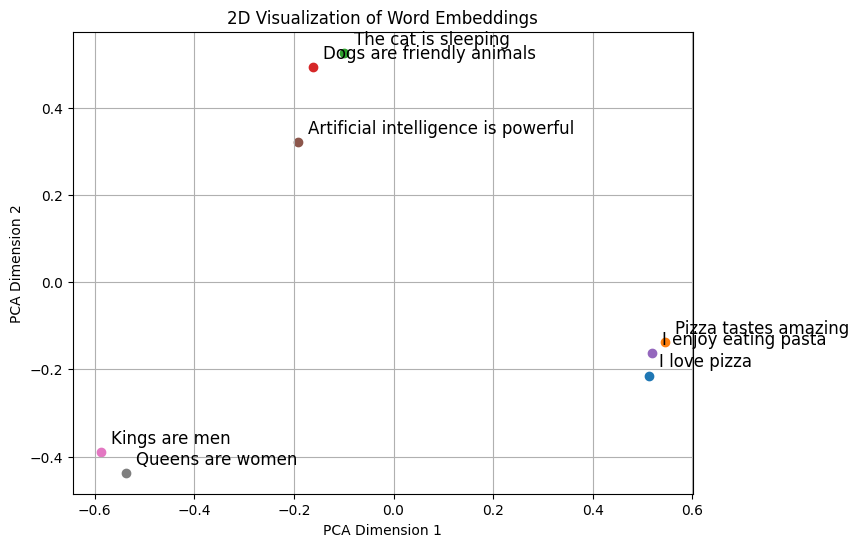

In [45]:
# Plot the embeddings in 2D

plt.figure(figsize=(8, 6))

for i, word in enumerate(sentences):

    x = reduced_embeddings[i, 0]
    y = reduced_embeddings[i, 1]

    plt.scatter(x, y)
    plt.text(x + 0.02, y + 0.02, word, fontsize=12)

plt.title("2D Visualization of Word Embeddings")

plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")

plt.grid(True)

plt.show()